# Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(12004)



In [2]:
def ecdf_xy(samples):
    x = np.sort(np.asarray(samples))
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y


def plot_ecdf_vs_cdf(samples, cdf, grid=None, title="", xlabel="", discrete=False, logx=False):
    x, y = ecdf_xy(samples)
    fig, ax = plt.subplots()
    ax.step(x, y, where="post", lw=2, label="simulation ECDF")

    if grid is None:
        lo, hi = np.quantile(x, [0.001, 0.999])
        grid = np.linspace(lo, hi, 400)
    if discrete:
        ax.step(grid, cdf(grid), where="post", lw=2, label="scipy CDF")
    else:
        ax.plot(grid, cdf(grid), lw=2, label="scipy CDF")

    if logx:
        ax.set_xscale("log")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("cumulative probability")
    ax.legend()
    return ax


def show_quantiles(samples, dist, probs=(0.1, 0.25, 0.5, 0.75, 0.9)):
    return pd.DataFrame({
        "p": probs,
        "simulation": np.quantile(samples, probs),
        "scipy": dist.ppf(probs),
    })

# Q1

In [3]:
K = 20
n = 5000

values_set = np.linspace(0,1,K+1)

draws = []
for i in range(n):
    draws.append(rng.choice(values_set))

Text(0.5, 1.0, 'ECDF of draws from uniform distribution')

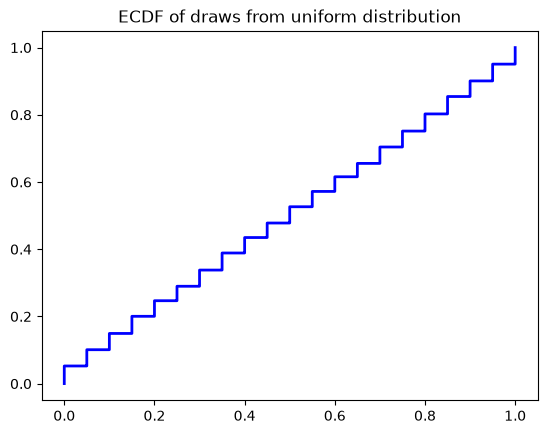

In [4]:
x, y = ecdf_xy(draws)

plt.step(x, y, where='post', color='blue', lw=2)
plt.title('ECDF of draws from uniform distribution')

4. It approaches a uniform distribution as K increases

# Q2

We often study sample averages: It's one of the first statistics you calculate for any dataset. What is the distribution of the sample mean?

1. Draw `n = 32` values from `Uniform[-sqrt(3), sqrt(3)]`; these are your data. The choice of $\pm \sqrt{3}$ ensures each draw has mean 0 and variance 1.
2. For this sample, compute the mean and multiply by `np.sqrt(n)`.
3. Repeat the above process `b = 5_000` times and plot the ECDF.
4. What distribution does this approach as $n$ increases?

In [5]:
b = 5000
n = 32
statistic = []

# Step 3
for i in range(b): # Sim loop
    values_set = []
    # Step 1
    for j in range(n):
        values_set.append(rng.uniform(-np.sqrt(3), np.sqrt(3)))
    # Step 2
    statistic.append(np.mean(values_set)*np.sqrt(n))

<Axes: title={'center': 'ECDF of 5000 samples from 32 uniform(-sqrt(3), sqrt(3)) draws'}, xlabel='mean * sqrt(n)', ylabel='cumulative probability'>

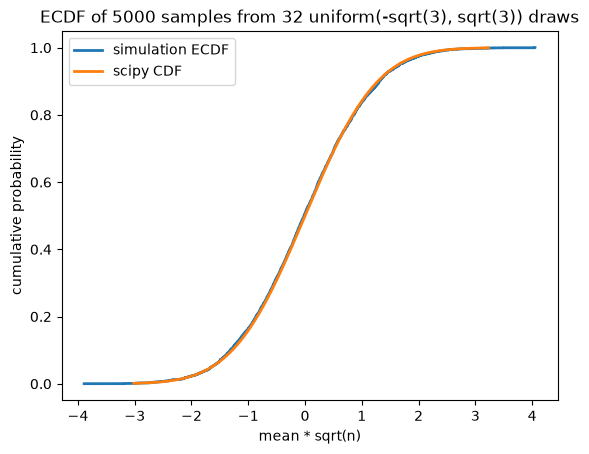

In [6]:

normal = stats.norm(0, 1)
plot_ecdf_vs_cdf(statistic, normal.cdf, title="ECDF of 5000 samples from 32 uniform(-sqrt(3), sqrt(3)) draws", xlabel="mean * sqrt(n)")

4. As n increases, it approaches a normal distribution as shown by the graph above

# Q4

**Q4.** 

A process is running in discrete time. In each time interval of length `dt`, it terminates with probability `r * dt`, where `r * dt < 1`. This is called an arrival, death, or survival process, and is popular for modeling how long patients live after a procedure, whether an employee quits, or the arrival of the next goal in a sportsball match.

1. For each simulation of the process, determine the period in which termination occurs.
2. Convert periods to time by multiplying by `dt`.
3. Repeat the simulation `n = 5_000` times and plot the ECDF, for a value of `dt` close to zero (e.g. `dt = 1e-3`).
4. What distribution does this approach as $dt$ goes to zero?
5. How do the results change as you adjust $r$?

<Axes: ylabel='cumulative probability'>

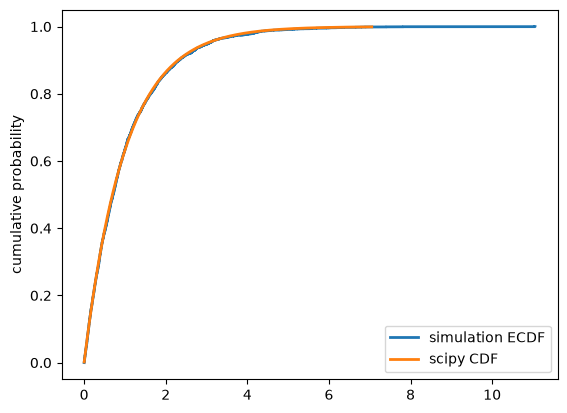

In [7]:
dt = 1e-3
r = 1
n = 5000
term_times = []
p = r * dt


for i in range(n): # sim loop
    period = 0
    terminated = False
    while terminated == False:
        period += 1
        if rng.uniform(0,1) < p:
            terminated = True
    time = period * dt
    term_times.append(time)

exponential = stats.expon(scale=1/r)
plot_ecdf_vs_cdf(term_times, exponential.cdf)


4. This approaches an exponential distribution. 
5. Higher r (r>1) makes the x axis shorter and runtime shorter. Lower r (r<1) makes runtime longer and the x axis longer. All still follow the exponential distribution.

# Q7

A surprising regularity appears again and again in human populations: the second-largest city is often roughly half the size of the largest, the third-largest roughly one-third the size, and so on. This relationship is called Zipf's law, and it connects the rank of an observation to its size.

1. Suppose there are `K = 100_000` cities, ranked from largest to smallest. Create the ranks $r= \{ 1,..., K\}$.
2. Zipf's law says that the size of the city with rank $r$ is proportional to
$ 
x_r = \left(K/r \right)^s. 
$
Start with $s=1$.
3. Randomly sample `n=5_000` ranks, with each rank equally likely, and record the corresponding sizes.
4. Plot the ECDF of the simulated sizes.
5. What distribution does this generate as $K$ becomes large?
6. How does the distribution change as you adjust $s$?


In [8]:
K = 100000
s = 1
n = 5000

ranks = np.arange(1, K+1)

sizes = []

for i in range(n):
    r = rng.choice(ranks)
    sizes.append((K/r)**s)



<Axes: title={'center': 'Simulated versus Pareto CDF'}, xlabel='Size', ylabel='cumulative probability'>

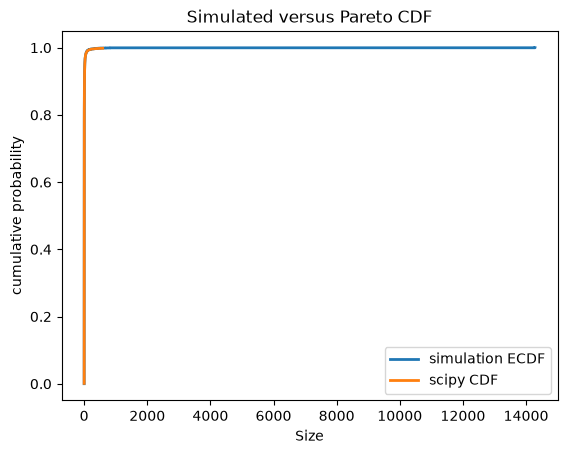

In [9]:
pareto = stats.pareto(b=1/s) # <- Had to talk to ChatGPT to figure out how parameter b works
plot_ecdf_vs_cdf(sizes, pareto.cdf, title="Simulated versus Pareto CDF", xlabel="Size")

5. As K becomes large, this approaches a pareto distribution.
6. Making s smaller makes the tail shorter, and the distribution more curve-like, wherease larger s makes the tail longer and has much higher values that make the curve look more like a right angle.

# AI Use 

I Used a conversation with GPT-5.6 to help me to figure out how to use stats.pareto in question 7.